# Dask quickstart — `FeatureCollection`

A vector table read lazily as partitions. `backend='dask'` returns a
`LazyFeatureCollection` (a partitioned dask-geopandas frame); partition-aware ops stay
lazy and you materialise with `.compute()`. Needs the `[parquet]` extra. For the full
surface see `lazy-feature-complete`.

## Setup

In [1]:
%matplotlib inline

from pathlib import Path

DATA = Path('../../../examples/data')
DATA.is_dir()

True

## Backend detection and a lazy read

In [2]:
from pyramids.feature import FeatureCollection, has_lazy_backend, is_lazy_fc

has_lazy_backend()

True

In [3]:
lfc = FeatureCollection.read_file(
    DATA / 'coello-gauges.geojson', backend='dask', npartitions=2
)
is_lazy_fc(lfc), type(lfc).__name__, lfc.npartitions

(True, 'LazyFeatureCollection', 2)

## Partition-aware ops

`to_crs` / `clip` stay lazy and keep returning a `LazyFeatureCollection`. The bounds are a
lazy reduction — `compute_total_bounds()` returns the 4-float array directly.

In [4]:
projected = lfc.to_crs(4326)
type(projected).__name__, projected.epsg, projected.compute_total_bounds()

('LazyFeatureCollection',
 4326,
 array([-75.5060754 ,   4.32493719, -75.11452282,   4.55188404]))

## Spatial join — partition-pruned

`spatial_shuffle` is a one-time cost that populates `spatial_partitions`; a subsequent
`sjoin` then prunes partition pairs that cannot intersect.

In [5]:
polys = FeatureCollection.read_file(
    DATA / 'coello_polygons.geojson', backend='dask', npartitions=2
).to_crs(4326)
gauges = projected.spatial_shuffle(by='hilbert')
polys = polys.spatial_shuffle(by='hilbert')
joined = gauges.sjoin(polys, how='inner', predicate='intersects')
type(joined).__name__, joined.npartitions

('LazyFeatureCollection', 2)

## Materialise and write

`compute()` returns an eager `FeatureCollection`. `to_parquet` is the only lazy-native
write for vectors (it writes a partitioned directory).

In [6]:
import tempfile

out = Path(tempfile.mkdtemp(prefix='pyramids-fc-')) / 'gauges.parquet'
lfc.to_parquet(out)
reopened = FeatureCollection.read_parquet(out, backend='dask')
reopened.npartitions, len(reopened.compute())

(2, 6)

`compute()` materialises the partitioned frame into an eager `FeatureCollection`, which we
can plot to see the gauge points the lazy pipeline carried through.

<Axes: >

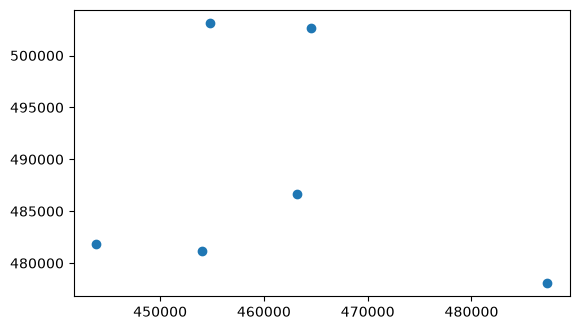

In [7]:
eager_fc = reopened.compute()
eager_fc.plot()

## Where to next

Three tiers for `FeatureCollection` + Dask:

- **Complete cookbook (offline)** —
  [Lazy `FeatureCollection`](../feature/lazy-feature-complete.ipynb): `persist`,
  scheduler config, the full method matrix.
- **Cloud (live data)** —
  [Dask on Overture Maps (AWS)](../feature/dask-lazy-features.ipynb): GeoParquet with
  Arrow pushdown filters.
- **Narrative guide** —
  the [Lazy vector reads tutorial](../../tutorials/lazy/lazy-vector.md).
- **All classes at a glance** — [the overview](overview.ipynb).